<a href="https://colab.research.google.com/github/1Anisa1/ComputerVisionPractice/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


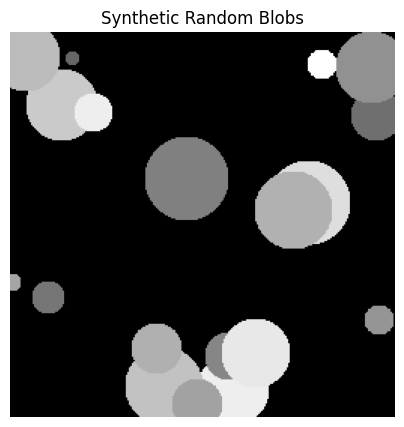

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import disk

# Image size
height, width = 256, 256

# Create empty image
image = np.zeros((height, width), dtype=np.float32)

# Number of blobs
num_blobs = 20

for _ in range(num_blobs):
    # Random center
    r = np.random.randint(0, height)
    c = np.random.randint(0, width)

    # Random radius
    radius = np.random.randint(5, 30)

    # Random intensity
    intensity = np.random.uniform(0.3, 1.0)

    rr, cc = disk((r, c), radius, shape=image.shape)
    image[rr, cc] = intensity

# Show result
plt.figure(figsize=(5,5))
plt.imshow(image, cmap='gray')
plt.title("Synthetic Random Blobs")
plt.axis('off')
plt.show()

Number of objects (including background): 36


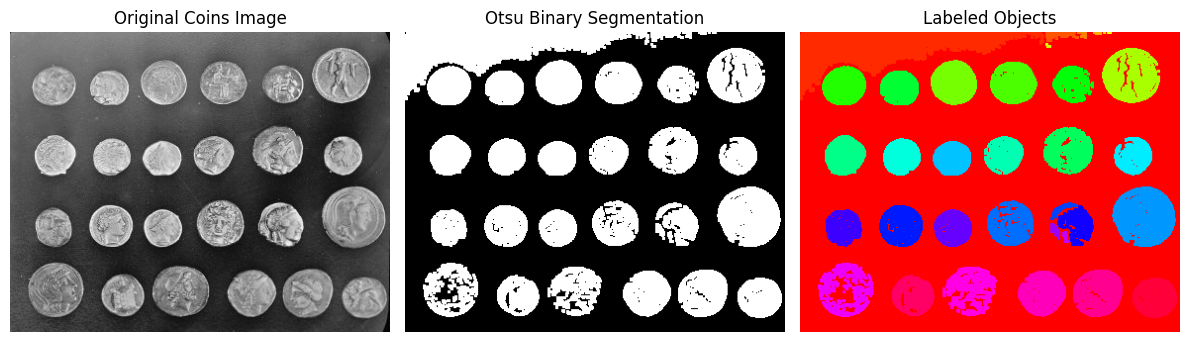

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import cv2

# -----------------------------
# 1. Load image (in-memory)
# -----------------------------
image = data.coins()

# -----------------------------
# 2. Otsu Thresholding (OpenCV)
# -----------------------------
# OpenCV expects uint8
img = image.astype(np.uint8)

_, binary = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Optional cleanup (helps segmentation quality)
kernel = np.ones((3, 3), np.uint8)
binary_clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# -----------------------------
# 3. Connected Components Labeling
# -----------------------------
num_labels, labels = cv2.connectedComponents(binary_clean)

print("Number of objects (including background):", num_labels)

# -----------------------------
# 4. Color labeling visualization
# -----------------------------
label_hue = np.uint8(179 * labels / np.max(labels))
blank = 255 * np.ones_like(label_hue)

colored_labels = cv2.merge([label_hue, blank, blank])
colored_labels = cv2.cvtColor(colored_labels, cv2.COLOR_HSV2RGB)

# -----------------------------
# 5. Visualization
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Coins Image")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Otsu Binary Segmentation")
plt.imshow(binary_clean, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Labeled Objects")
plt.imshow(colored_labels)
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
from skimage import data
from skimage.measure import label, regionprops_table
import cv2

# -----------------------------
# 1. Load image
# -----------------------------
image = data.coins().astype(np.uint8)

# -----------------------------
# 2. Otsu segmentation
# -----------------------------
_, binary = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Optional cleanup (recommended)
kernel = np.ones((3, 3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# -----------------------------
# 3. Label connected components (skimage version)
# -----------------------------
labels = label(binary)

# -----------------------------
# 4. Extract region properties into DataFrame
# -----------------------------
props = regionprops_table(
    labels,
    intensity_image=image,
    properties=(
        "label",
        "area",
        "bbox",
        "centroid",
        "mean_intensity",
        "eccentricity"
    )
)

df = pd.DataFrame(props)

# -----------------------------
# 5. Show results
# -----------------------------
print(df.head())

print("\nTotal objects detected:", len(df))

   label    area  bbox-0  bbox-1  bbox-2  bbox-3  centroid-0  centroid-1  \
0      1  6659.0       0       0      69     247   16.893678   88.136507   
1      2   216.0       0     248      10     282    3.217593  261.962963   
2      3    50.0       0     280       7     290    2.480000  285.580000   
3      4    25.0       0     296       3     305    0.920000  300.280000   
4      5     6.0       0     306       2     309    0.500000  307.000000   

   mean_intensity  eccentricity  
0      120.424388      0.984156  
1      111.837963      0.970960  
2      111.420000      0.763922  
3      109.640000      0.948411  
4      111.166667      0.790569  

Total objects detected: 35


In [30]:
# Compute average area
mean_area = df["area"].mean()

# Filter blobs above average
above_avg = df[df["area"] > mean_area]

# Count them
count_above_avg = len(above_avg)

print("Average blob area:", mean_area)
print("Number of blobs above average area:", count_above_avg)

Average blob area: 1245.8285714285714
Number of blobs above average area: 16


In [31]:
import numpy as np
import pandas as pd
import cv2

from skimage import data
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops

# -----------------------------
# 1. Load image
# -----------------------------
image = data.coins().astype(np.uint8)

# -----------------------------
# 2. Otsu segmentation
# -----------------------------
_, binary = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Cleanup
kernel = np.ones((3, 3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# -----------------------------
# 3. Label blobs
# -----------------------------
labels = label(binary)

# -----------------------------
# 4. Extract texture features per region
# -----------------------------
rows = []

for region in regionprops(labels, intensity_image=image):

    if region.area < 50:  # skip tiny noise regions
        continue

    minr, minc, maxr, maxc = region.bbox
    patch = image[minr:maxr, minc:maxc]

    # Normalize patch to reduce intensity bias
    patch = (patch / 16).astype(np.uint8)

    # Compute GLCM
    glcm = graycomatrix(
        patch,
        distances=[1],
        angles=[0],
        levels=16,
        symmetric=True,
        normed=True
    )

    # Extract texture properties
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    rows.append({
        "label": region.label,
        "area": region.area,
        "contrast": contrast,
        "dissimilarity": dissimilarity,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation
    })

# -----------------------------
# 5. Create DataFrame
# -----------------------------
df_texture = pd.DataFrame(rows)

# -----------------------------
# 6. Show results
# -----------------------------
print(df_texture.head())
print("\nTotal regions analyzed:", len(df_texture))

   label    area  contrast  dissimilarity  homogeneity    energy  correlation
0      1  6659.0  1.007423       0.441970     0.824337  0.348609     0.870509
1      2   216.0  0.160606       0.160606     0.919697  0.633685     0.653591
2      3    50.0  0.492063       0.492063     0.753968  0.508061    -0.000256
3      8  2416.0  3.848522       1.316502     0.545279  0.167209     0.763948
4      9  1680.0  2.230151       0.883270     0.661271  0.238165     0.795654

Total regions analyzed: 30
